# From Prompt to Tool Calling

---

## Before we touch any code — what problem are we solving?

Imagine you hire a brilliant new employee. They are incredibly knowledgeable — they can write, explain, summarise, and reason about almost anything.

But there is one catch: **they cannot pick up the phone.**

They cannot call your warehouse to check stock. They cannot log into your booking system. They cannot look up today's exchange rate. They only know what was in their training — nothing that happened since, and nothing specific to your business.

**Tool calling is how you give them a phone.**

You create a list of "phones" — each one connected to a different system. You hand them the list. Now, when a customer asks "Is the Laptop Pro in stock?", your employee does not guess. They pick up the right phone, get the real answer, and tell the customer.

---

## What you will build today

A step-by-step retail assistant called **ShopBot** that can:
- Look up real product prices from a catalogue
- Check stock availability
- Calculate totals with discounts

By the end, you will understand not just *how* tool calling works, but *why* each piece exists.

---

## How to read this notebook

| Symbol | Means |
|--------|-------|
| 📖 | Read this before running the cell |
| 🔍 | Look closely — this is the key idea |
| ▶️ | Run this cell (click it, then Shift+Enter) |
| ✏️ | Change something and try it yourself |
| 💬 | Discussion question for the group |
| 🚧 | A limitation we are about to solve |

**Run every cell in order, top to bottom. Do not skip any.**

---
## 🗺️ How This Notebook Flows — Read This First

These two diagrams show the full journey before you run a single cell. Come back to them any time you feel lost.

**Diagram 1** shows the whole notebook as a swimlane — one column per actor, one row per section.

**Diagram 2** zooms into the loop that powers the final ShopBot — what happens step by step each time a tool is called.

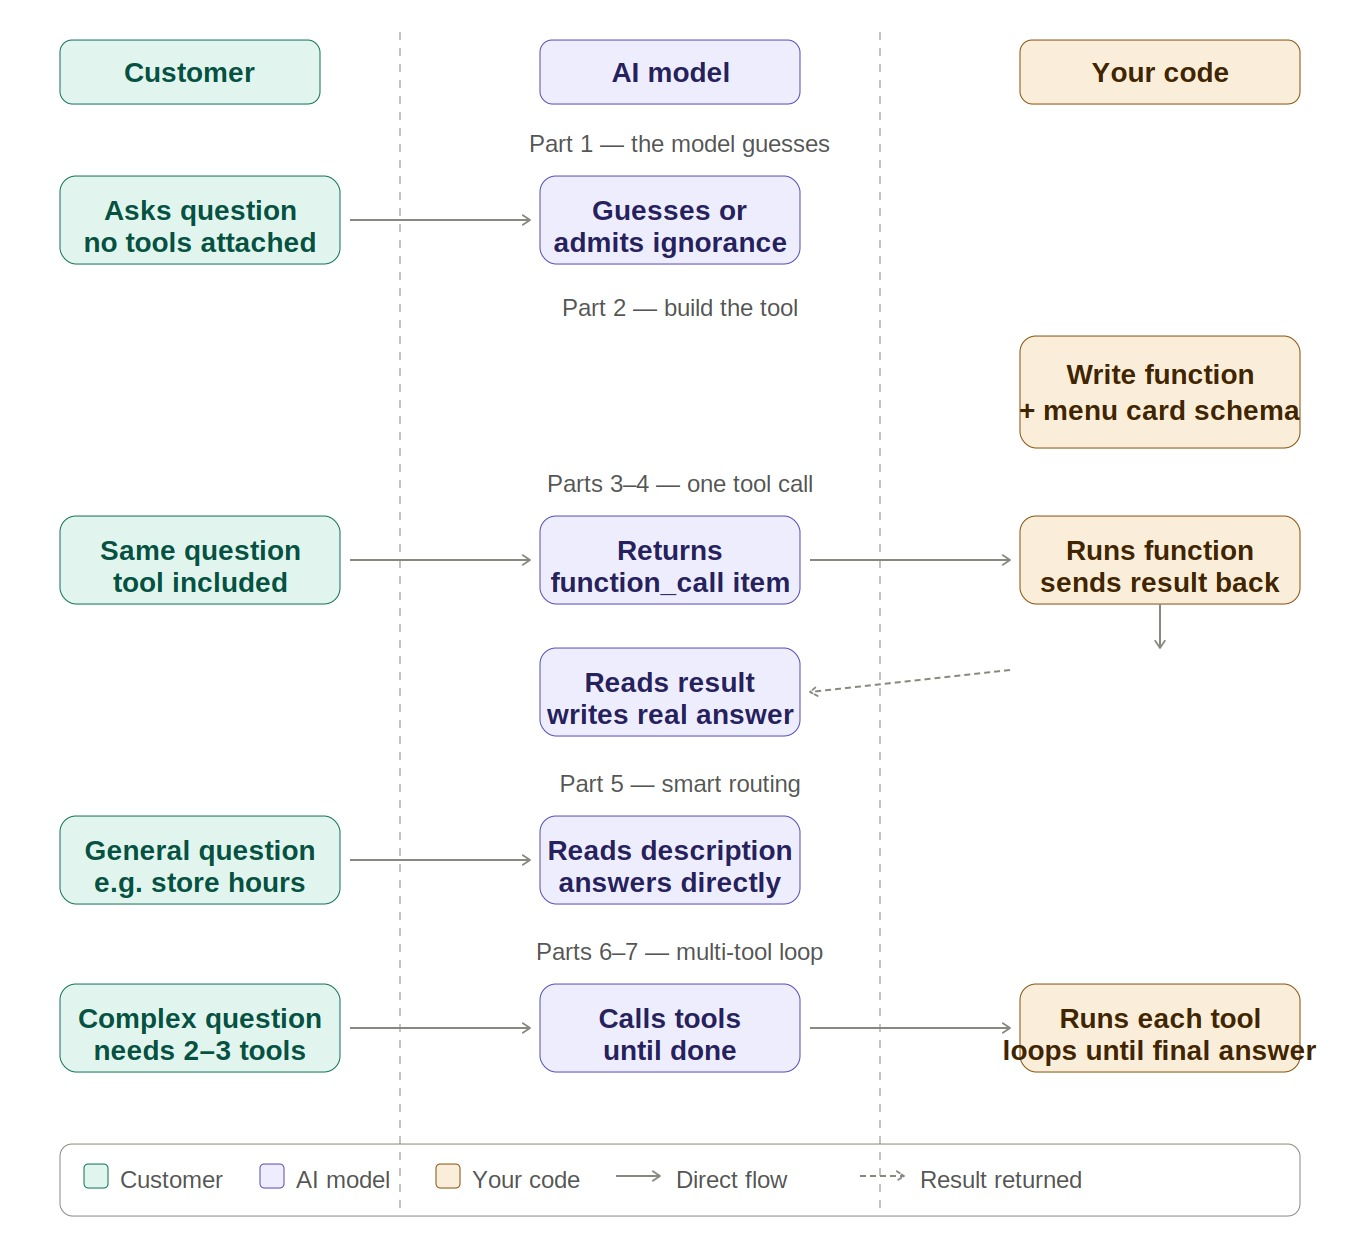

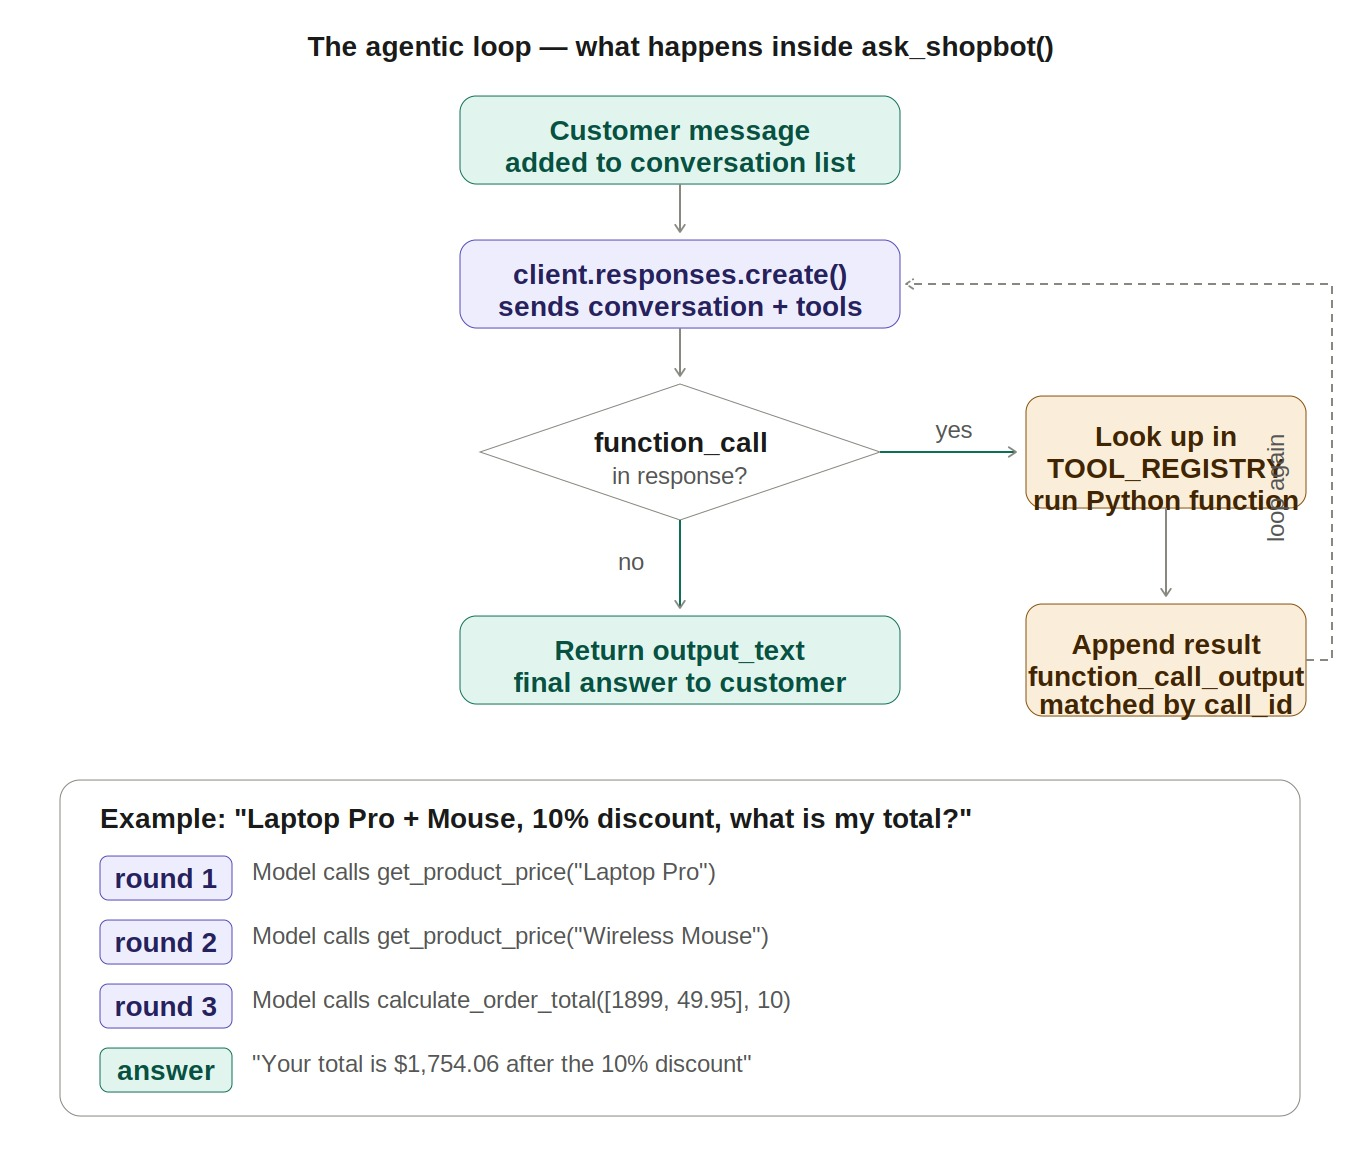

---
## ⚙️ Setup — Run These First

These two cells get everything ready. You only need to do this once per session.

*(Diagram styles loaded — nothing to display here.)*

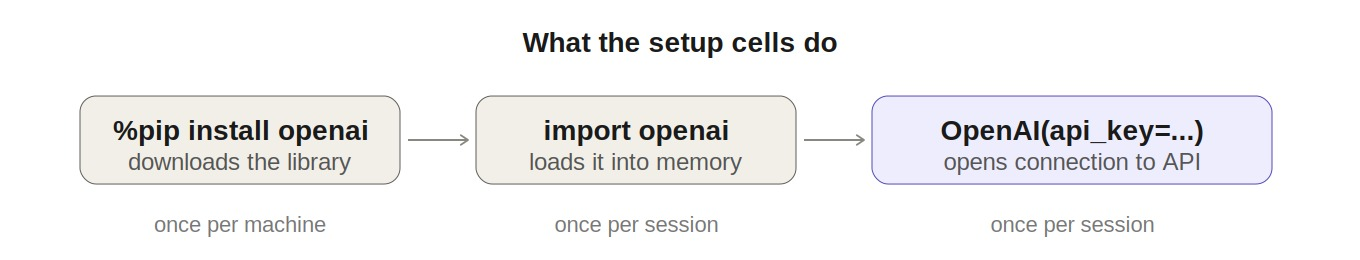

In [ ]:
# This installs the OpenAI library — a package that handles the
# technical details of talking to the API.
# The --quiet flag just suppresses a wall of installation text.

%pip install openai --quiet
print("✅ Library installed")

In [ ]:
import openai   # loads the library we just installed
import json     # handles converting between Python and text format

# ── YOUR API KEY ──────────────────────────────────────────────
# This is your password for the OpenAI API.
# Get one at: platform.openai.com → API keys → Create new secret key
#
# 💡 Safer option — use Colab Secrets instead of pasting here:
#    Click the 🔑 icon in the left panel, add OPENAI_API_KEY,
#    then replace the line below with:
#    from google.colab import userdata
#    API_KEY = userdata.get("OPENAI_API_KEY")

API_KEY = "sk-..."  # ← paste your key here

client = openai.OpenAI(api_key=API_KEY)
MODEL  = "gpt-4o-mini"

print("✅ Ready to go")

---
# Part 1 — The Problem: The Model Doesn't Know Your Data

📖 Before we add any tools, let's see exactly what the model *cannot* do on its own.

We will ask it a simple business question and watch it either guess or admit it doesn't know.

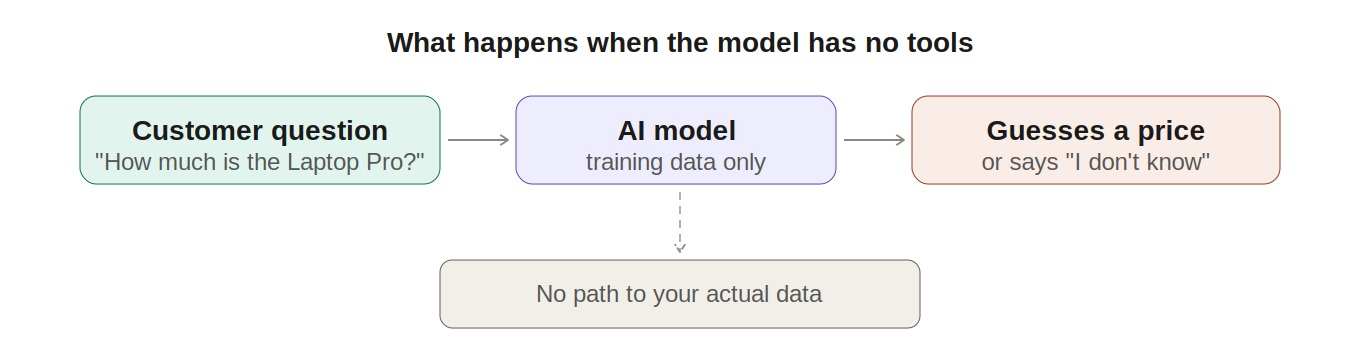

In [ ]:
# A customer walks up and asks about a specific product.
# Let's see what the model says with NO extra information.

response = client.responses.create(
    model=MODEL,
    input=[{"role": "user", "content": "How much does the Laptop Pro cost and is it in stock?"}]
)

print(response.output_text)

### 🔍 What did you notice?

The model either:
- **Made up a price** (hallucinated) — dangerous for a real business
- **Admitted it doesn't know** — honest, but useless to the customer

Either way, the model has no access to *your* product catalogue. It only knows what was baked into its training data months ago.

### 💬 Discussion
In your industry, what kinds of questions would an AI assistant *always* get wrong without access to live data?

---
# Part 2 — The Solution: Give the Model a "Phone"

📖 We are going to create a tool. A tool has two completely separate parts — and keeping them separate in your mind is the most important concept in this notebook.

```
┌─────────────────────────────────────┐   ┌──────────────────────────────────┐
│         THE MENU CARD               │   │       THE ACTUAL KITCHEN         │
│         (what the MODEL sees)       │   │       (what YOUR CODE runs)      │
│                                     │   │                                  │
│  Tool name: get_product_price       │   │  def get_product_price(name):    │
│  Does: looks up price & stock       │   │      look in catalogue dict      │
│  Needs: a product name (text)       │   │      return price, stock info    │
│                                     │   │                                  │
│  The model reads this and decides   │   │  You write this. It runs on      │
│  WHEN to ask for this tool.         │   │  your computer, not OpenAI's.    │
└─────────────────────────────────────┘   └──────────────────────────────────┘
```

The model **never sees your code**. It only sees the menu card. Your code **never decides when to run** — the model decides that.

---
## 2a — First, Our Fake Database

📖 In a real business, your tool would connect to a real database, a live API, or a spreadsheet. For this demo, we use a Python dictionary as a stand-in. The concept is identical — only the data source changes.

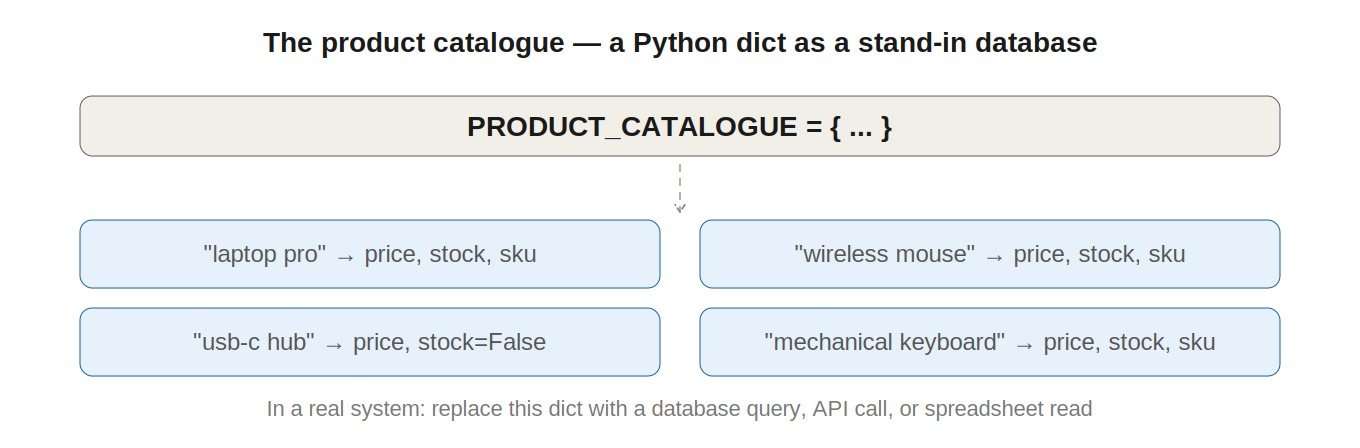

In [ ]:
# Think of this as a very simple spreadsheet stored in Python.
# Each product name maps to a row of information.
#
# In a real system this might be:
#   - A SQL database query
#   - A call to your inventory API
#   - A read from a Google Sheet

PRODUCT_CATALOGUE = {
    "laptop pro":          {"price": 1899.00, "in_stock": True,  "stock_count": 12, "sku": "LP-001"},
    "wireless mouse":      {"price":   49.95, "in_stock": True,  "stock_count": 84, "sku": "WM-204"},
    "usb-c hub":           {"price":   89.00, "in_stock": False, "stock_count":  0, "sku": "UC-512"},
    "mechanical keyboard": {"price":  199.00, "in_stock": True,  "stock_count": 27, "sku": "MK-088"},
}

# Let's just look at it to confirm it works
print("Our product catalogue:")
for product, details in PRODUCT_CATALOGUE.items():
    status = "✅ In stock" if details["in_stock"] else "❌ Out of stock"
    print(f"  {product.title():25s} ${details['price']:>8.2f}  {status}")

---
## 2b — The Python Function (the Kitchen)

📖 This is the actual code that runs when the tool is called. It takes a product name, looks it up in our catalogue, and returns the result.

Read it line by line — every line has a comment explaining what it does.

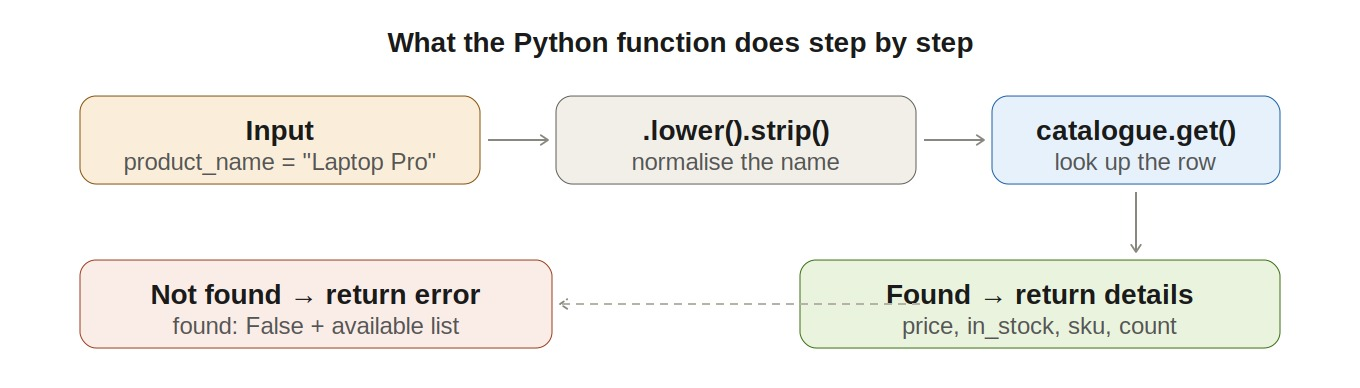

In [ ]:
def get_product_price(product_name: str) -> dict:
    # product_name: str   means this function expects a piece of text
    # -> dict             means it will return a dictionary of results

    # .lower() converts "Laptop Pro" → "laptop pro" so our lookup works
    # regardless of how the model capitalises the name
    lookup_key = product_name.lower().strip()

    # Check if the product exists in our catalogue
    product = PRODUCT_CATALOGUE.get(lookup_key)

    if product:
        # Found it — return all the details
        return {
            "found":       True,
            "name":        product_name,
            "price_aud":   product["price"],
            "in_stock":    product["in_stock"],
            "stock_count": product["stock_count"],
            "sku":         product["sku"],
        }
    else:
        # Not found — tell the model so it can inform the customer
        available = list(PRODUCT_CATALOGUE.keys())
        return {
            "found":     False,
            "name":      product_name,
            "message":   f"Product not found. We carry: {available}",
        }


# ── TEST IT DIRECTLY ──────────────────────────────────────────
# Always test your function on its own before connecting it to the model.
# This is like tasting the food before serving it.

print("Test 1 — product that exists:")
print(get_product_price("Laptop Pro"))

print()
print("Test 2 — product that doesn't exist:")
print(get_product_price("Hoverboard"))

---
## 2c — The Menu Card (what the Model Sees)

📖 Now we write the **description** of our tool — the menu card. This is a structured description that tells the model:
- What the tool is called
- What it does (in plain English — **the model reads this literally**)
- What information it needs to run

This is written in a format called **JSON** — just nested labels and values, like a very structured form.

🔍 **Pay special attention to the `description` fields.** The model uses these descriptions — not the code — to decide when and how to use the tool. Bad descriptions = bad tool use.

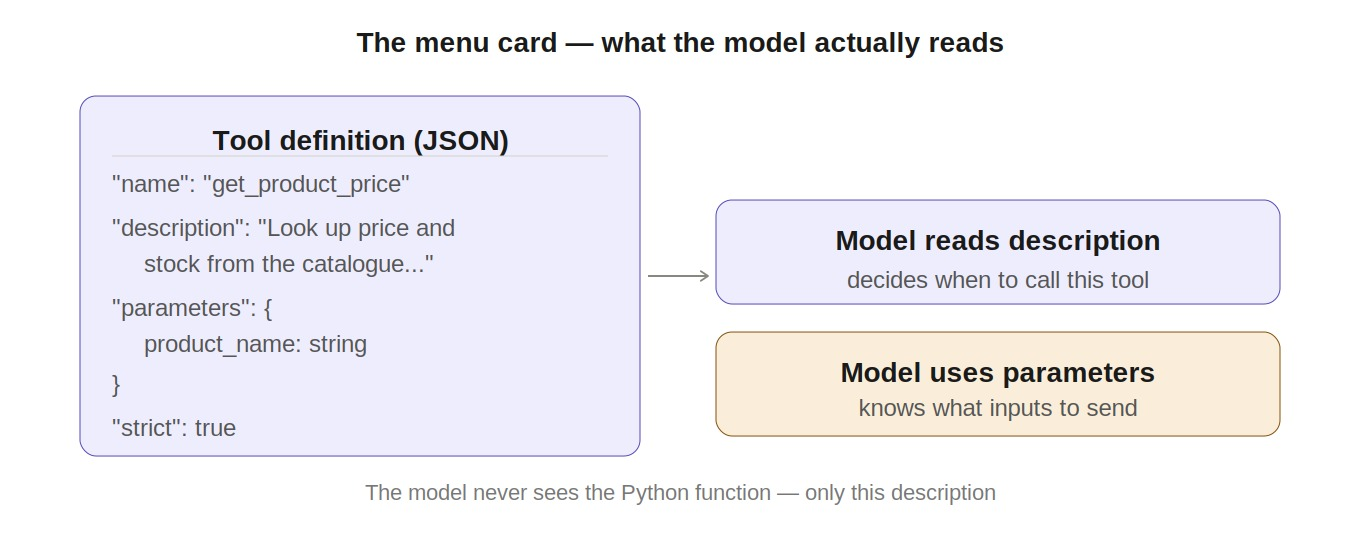

In [ ]:
# ── THE MENU CARD ────────────────────────────────────────────
# This is what gets sent to the model.
# The model reads the "description" fields to understand the tool.

get_product_price_tool = {

    "type": "function",           # tells OpenAI this is a callable function

    "name": "get_product_price",  # must exactly match the Python function name above

    "description": (              # THE MOST IMPORTANT FIELD
        "Look up the current price and stock availability of a product "
        "from the TechMart catalogue. Use this whenever a customer asks "
        "about a product's price, cost, availability, or whether it is in stock."
    ),

    "parameters": {               # describes what inputs the tool needs
        "type": "object",
        "properties": {
            "product_name": {
                "type": "string",                              # must be text
                "description": "The product name to look up, "
                               "e.g. 'Laptop Pro' or 'Wireless Mouse'"
            }
        },
        "required": ["product_name"],    # product_name is not optional
        "additionalProperties": False    # don't accept any extra fields
    },

    "strict": True   # force the model to follow our schema exactly
}

print("✅ Menu card defined")
print()
print("The model will see a tool called:", get_product_price_tool["name"])
print("It will use it when:", get_product_price_tool["description"])

### 💬 Discussion

Look at the `description` field. Now imagine you are the AI model reading it.

Would you know when to use this tool? What if the description just said `"Gets product info"` — would that be better or worse? Why does the quality of this description matter so much?

---
# Part 3 — Watching the Model Ask for the Tool

📖 Now we send the same question as Part 1, but this time we pass the tool along with it.

Watch what the model does differently.

```
BEFORE (Part 1):          AFTER (Part 3):
User asks question         User asks question
      ↓                          ↓
Model guesses or           Model reads the question
admits ignorance           + reads the menu card
                                 ↓
                           Model says: "I need to call
                           get_product_price('Laptop Pro')"
                                 ↓
                           Model PAUSES and waits
```

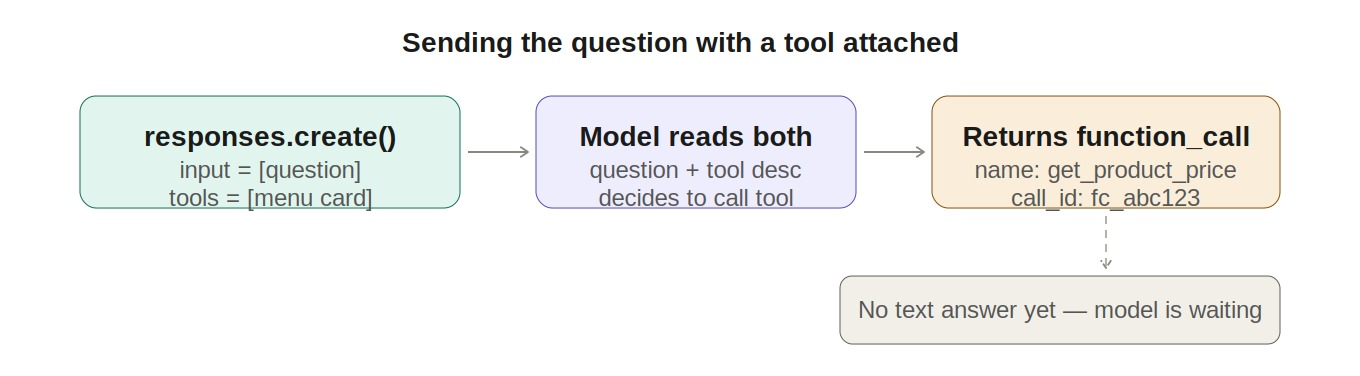

In [ ]:
# Same question as Part 1 — but now we include the tool

customer_question = "How much does the Laptop Pro cost and is it in stock?"

response = client.responses.create(
    model=MODEL,
    input=[{"role": "user", "content": customer_question}],
    tools=[get_product_price_tool]   # 👈 this is the only new thing
)

# Let's see what came back
print("What did the model return?")
print()
for item in response.output:
    print(f"  Item type: {item.type}")

### 🔍 The model did NOT answer the question

Instead of giving a response, it returned a `function_call` item. It is saying:

> *"I've read the question and I can see there is a tool that would help. Please run that tool for me and send me the result."*

The model has **paused**. It is waiting for us.

Let's look at exactly what it asked for.

In [ ]:
# Find the function_call item and inspect it closely

for item in response.output:
    if item.type == "function_call":

        print("The model wants to call a tool.")
        print()
        print(f"  Tool name : {item.name}")
        print(f"  With input: {item.arguments}")
        print(f"  Call ID   : {item.call_id}")
        print()
        print("In plain English:")
        print(f"  → Please run get_product_price() with product_name = 'Laptop Pro'")
        print(f"  → When you have the result, send it back tagged with ID: {item.call_id}")

---
# Part 4 — Running the Tool and Sending the Result Back

📖 The model has asked for a tool. Now **we** have to:
1. Actually run the Python function
2. Package up the result
3. Send everything back to the model so it can answer

Think of it like this: the model sent us a note saying "can you please check the price of the Laptop Pro?" We go check, write the answer on a note, and hand it back.

The `call_id` is how we label the note so the model knows which question it answers.

```
Model → "Run get_product_price('Laptop Pro'), call_id = abc123"
                    ↓
         We run get_product_price("Laptop Pro")
         Result: {price: 1899.00, in_stock: True, ...}
                    ↓
We send back → call_id: abc123, result: {price: 1899.00, ...}
                    ↓
         Model reads the result and answers the customer
```

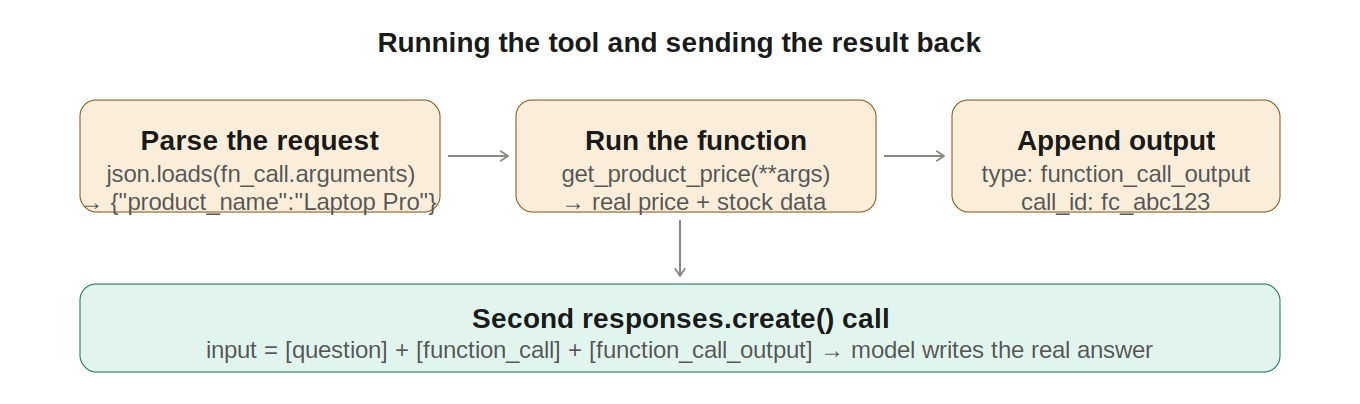

In [ ]:
# Step 1: Find what the model asked for
fn_call = next(item for item in response.output if item.type == "function_call")

print(f"Model asked for: {fn_call.name}")
print(f"With arguments : {fn_call.arguments}")
print()

# Step 2: Parse the arguments and run our Python function
# fn_call.arguments is a text string like '{"product_name": "Laptop Pro"}'
# json.loads() converts that text into a Python dictionary
arguments = json.loads(fn_call.arguments)

print(f"Running get_product_price(product_name='{arguments['product_name']}')")
tool_result = get_product_price(**arguments)

print(f"Result: {tool_result}")

In [ ]:
# Step 3: Send everything back to the model
#
# We build a new input list with three parts:
#   [original question] + [model's function_call] + [our tool result]
#
# This gives the model the full picture: what was asked, what it requested,
# and what we found.

full_input = (
    [{"role": "user", "content": customer_question}]   # the original question
    + response.output                                   # the model's function_call
    + [{                                                # our tool result
        "type":    "function_call_output",
        "call_id": fn_call.call_id,                    # links result to the request
        "output":  json.dumps(tool_result)             # result as text
    }]
)

# Step 4: Call the model again — this time it has the data it needs
final_response = client.responses.create(
    model=MODEL,
    input=full_input,
    tools=[get_product_price_tool]
)

print("=" * 55)
print("🤖 ShopBot's answer:")
print("=" * 55)
print(final_response.output_text)

### ✅ What just happened — in plain English

| Step | Who acted | What happened |
|------|-----------|---------------|
| 1 | You | Sent the customer's question + the tool menu card |
| 2 | Model | Read the question, chose to use `get_product_price` |
| 3 | Model | Paused and returned a `function_call` — telling you what to run |
| 4 | You | Ran the Python function, got real data |
| 5 | You | Sent the result back to the model |
| 6 | Model | Read the real data and wrote a proper answer |

The model made the decision. You did the fetching. Neither could do it alone.

### 💬 Discussion
Why can't we just let the model run the Python function itself? Why do *we* have to be in the middle?

---
# Part 5 — The Model Only Calls Tools When It Needs To

📖 One concern students often have: *"Does the model call the tool for every single message, even when it doesn't need to?"*

No. The model reads the question and the tool description, and makes a decision. Let's verify.

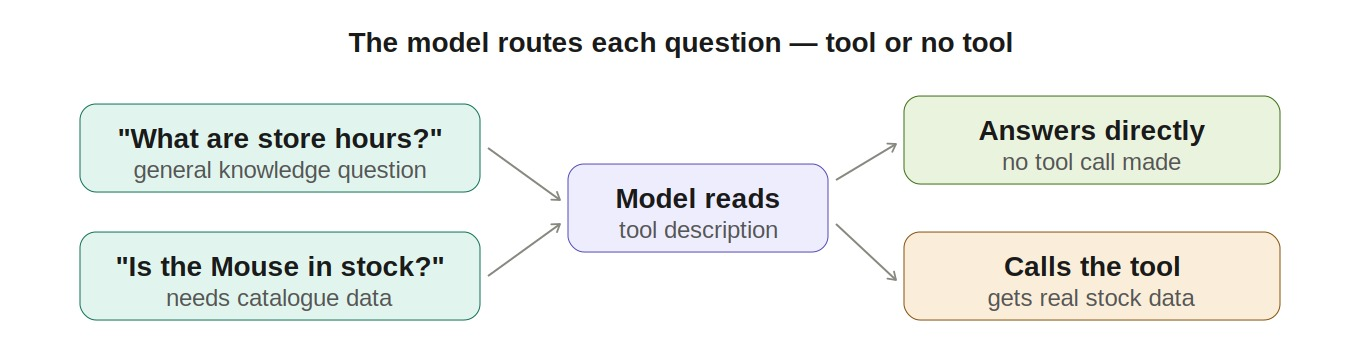

In [ ]:
# A question that does NOT need a product lookup

general_question = "What are your store opening hours?"

response = client.responses.create(
    model=MODEL,
    instructions="You are ShopBot, the assistant for TechMart electronics. "
                 "Store hours: Mon-Sat 9am-6pm, Sun 10am-5pm. Melbourne CBD.",
    input=[{"role": "user", "content": general_question}],
    tools=[get_product_price_tool]
)

# Check what items came back
fn_calls = [item for item in response.output if item.type == "function_call"]

print(f"Tool calls made: {len(fn_calls)}")
print()
print("Direct answer:")
print(response.output_text)

In [ ]:
# Now a question that DOES need the tool

product_question = "Is the Wireless Mouse available?"

response = client.responses.create(
    model=MODEL,
    instructions="You are ShopBot, the assistant for TechMart electronics.",
    input=[{"role": "user", "content": product_question}],
    tools=[get_product_price_tool]
)

fn_calls = [item for item in response.output if item.type == "function_call"]
print(f"Tool calls made: {len(fn_calls)}")

if fn_calls:
    print(f"Tool requested: {fn_calls[0].name}")
    print(f"With input    : {fn_calls[0].arguments}")

### 🔍 The key

The model reads the **description** in your tool definition and uses it to decide:
- *"Does this question require information that `get_product_price` would provide?"*
- If yes → call the tool
- If no → answer directly

This is why writing a clear, specific `description` is the most important part of building a tool.

---
# Part 6 — Adding a Second Tool

📖 Real assistants need more than one tool. Let's add a discount calculator.

Notice the pattern: we always do the same two things for every tool:
1. Write the Python function (the kitchen)
2. Write the menu card description (what the model sees)

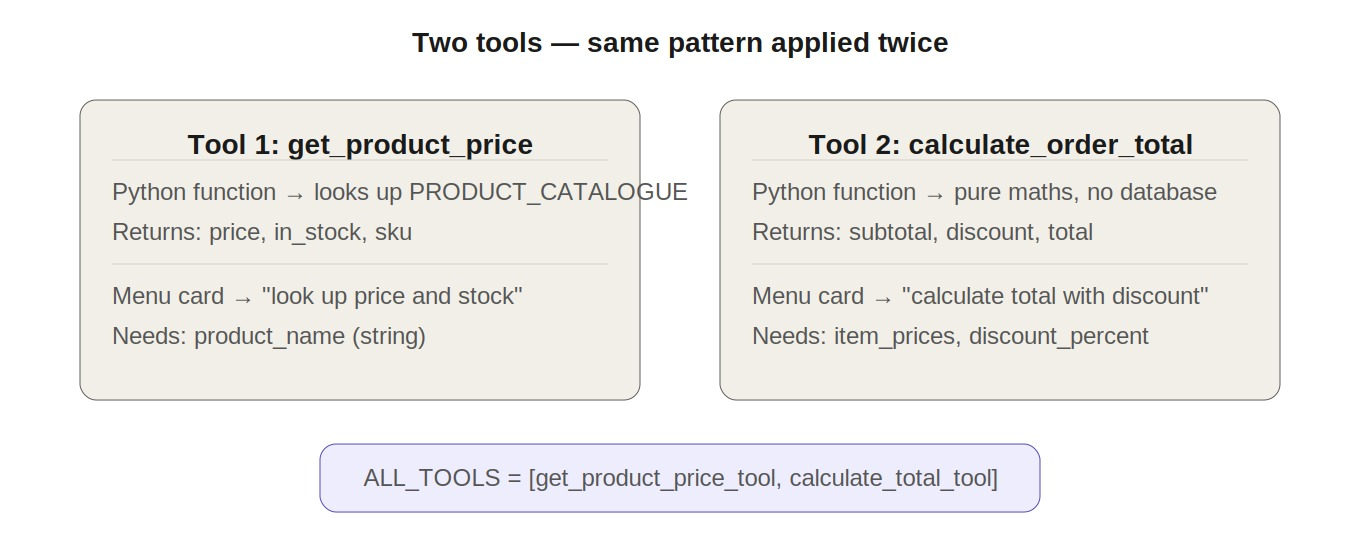

In [ ]:
# ── THE PYTHON FUNCTION ──────────────────────────────────────
# This one does pure maths — no database needed.
# We use a tool for this rather than letting the model calculate,
# because LLMs can make arithmetic errors on complex calculations.

def calculate_order_total(item_prices: list, discount_percent: float) -> dict:
    # item_prices is a list of numbers, e.g. [1899.00, 49.95]
    # discount_percent is a number like 10 (meaning 10% off)

    subtotal        = sum(item_prices)                              # add up all items
    discount_amount = round(subtotal * discount_percent / 100, 2)  # calculate saving
    total           = round(subtotal - discount_amount, 2)          # final price

    return {
        "subtotal":        subtotal,
        "discount_percent": discount_percent,
        "you_save":        discount_amount,
        "total_to_pay":    total,
        "currency":        "AUD",
    }


# Test it
print("Order total test:")
print(calculate_order_total(item_prices=[1899.00, 49.95], discount_percent=10))

In [ ]:
# ── THE MENU CARD ─────────────────────────────────────────────

calculate_total_tool = {
    "type": "function",
    "name": "calculate_order_total",
    "description": (
        "Calculate the total cost of an order with an optional discount. "
        "Use this after looking up individual product prices when the customer "
        "wants to know their total, or when a discount needs to be applied."
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "item_prices": {
                "type": "array",
                "items": {"type": "number"},
                "description": "A list of item prices in AUD, e.g. [1899.00, 49.95]"
            },
            "discount_percent": {
                "type": "number",
                "description": "The discount percentage. Use 0 if no discount applies."
            }
        },
        "required": ["item_prices", "discount_percent"],
        "additionalProperties": False
    },
    "strict": True
}

# Both tools in one list — this is what we'll pass to the model
ALL_TOOLS = [get_product_price_tool, calculate_total_tool]

print("✅ Both tools ready:")
for tool in ALL_TOOLS:
    print(f"   • {tool['name']}")

---
# Part 7 — Handling Multiple Tool Calls Automatically

📖 Here is a realistic customer question:

> *"I'd like to buy a Laptop Pro and a Wireless Mouse. With a 10% staff discount, what's my total?"*

To answer this, the model needs to:
1. Look up the Laptop Pro price → **tool call 1**
2. Look up the Wireless Mouse price → **tool call 2**
3. Calculate the total with discount → **tool call 3**
4. Write the final answer

That is **three tool calls** before it can respond. We need a loop that keeps running until the model has everything it needs and produces a final answer.

```
                    ┌─────────────────────────────────┐
                    │                                 │
Ask question   →  Model          ← Send tool results │
                    │                                 │
                    ↓ (needs a tool?)                 │
                   Yes → We run the tool ─────────────┘
                    │
                    ↓ (needs another tool?)
                   Yes → We run the tool ─────────────┐
                    │                                 │
                    ↓ (needs another tool?)           │
                   No  → Final answer                 │
                                                      │
                    ← (keep going until here) ────────┘
```

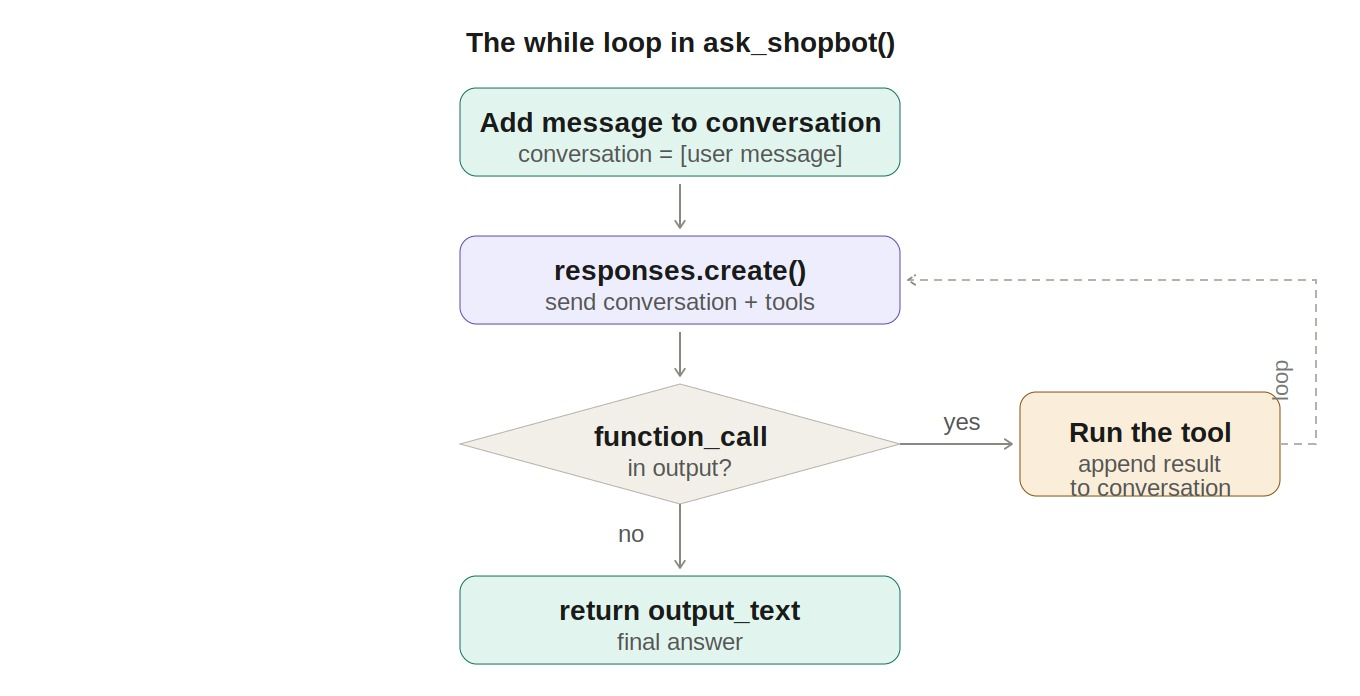

In [ ]:
# ── THE TOOL RUNNER ──────────────────────────────────────────
# This is a lookup table: tool name → Python function.
# When the model asks for a tool by name, we look it up here
# and call the right function.

TOOL_REGISTRY = {
    "get_product_price":    get_product_price,
    "calculate_order_total": calculate_order_total,
}

print("Tool registry:")
for name in TOOL_REGISTRY:
    print(f"  '{name}' → our Python function")

In [ ]:
# ── THE LOOP ──────────────────────────────────────────────────
# This function handles the back-and-forth automatically.
# It keeps going until the model stops asking for tools
# and gives us a final text answer.

def ask_shopbot(customer_message: str) -> str:

    # Start with just the customer's message
    conversation = [{"role": "user", "content": customer_message}]

    print(f"Customer: {customer_message}")
    print()

    round_number = 0

    while True:   # keep looping until we break out

        round_number += 1

        # Send the current conversation to the model
        response = client.responses.create(
            model=MODEL,
            instructions="You are ShopBot, a helpful assistant for TechMart electronics. "
                         "Always use the available tools to look up real prices and stock. "
                         "Be friendly and give clear, specific answers.",
            input=conversation,
            tools=ALL_TOOLS
        )

        # Check if the model wants any tools
        tool_requests = [item for item in response.output
                         if item.type == "function_call"]

        if not tool_requests:
            # No tool calls — the model has its answer
            print(f"  Round {round_number}: Model has enough info → writing answer")
            break   # exit the loop

        # The model wants tools — run each one
        print(f"  Round {round_number}: Model needs {len(tool_requests)} tool(s)")

        # Add the model's requests to our conversation
        conversation += response.output

        # Run each requested tool and add results to the conversation
        for request in tool_requests:
            fn       = TOOL_REGISTRY[request.name]           # find the right function
            args     = json.loads(request.arguments)          # parse the inputs
            result   = fn(**args)                             # run it
            result_str = json.dumps(result)

            print(f"    🔧 {request.name}({args})")
            print(f"    📦 Result: {result_str}")

            # Add the result — tagged with call_id so the model knows which
            # request this answers
            conversation.append({
                "type":    "function_call_output",
                "call_id": request.call_id,
                "output":  result_str
            })

    # Return the final answer
    return response.output_text


print("✅ ask_shopbot() is ready")

---
# Part 8 — Let's Test It

📖 Now run some real customer questions. Watch the output to see how many tool calls the model makes for each one.

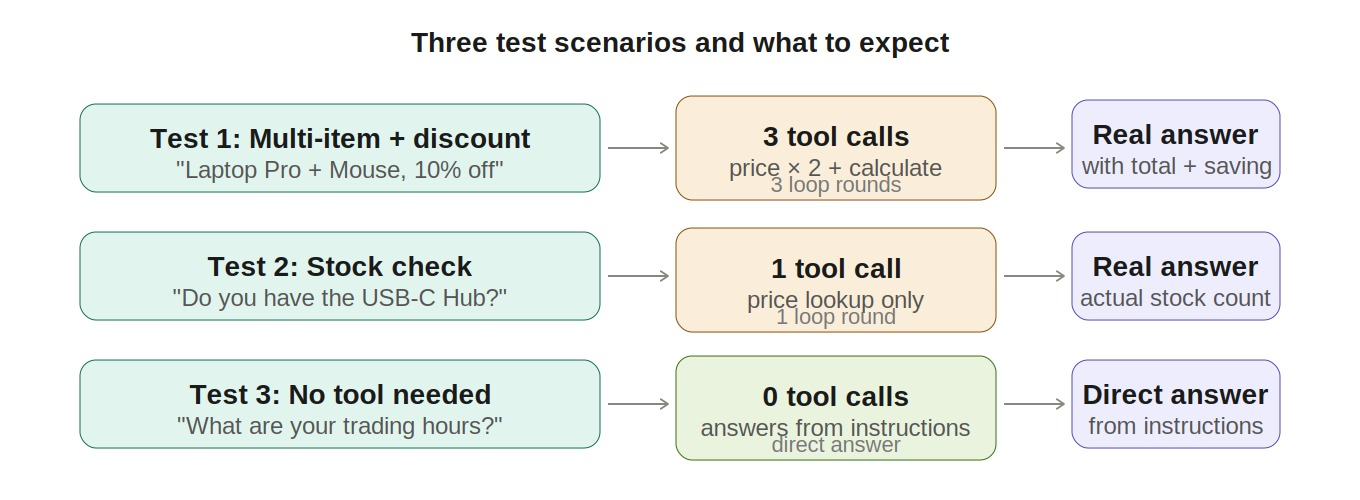

In [ ]:
# Test 1: Multi-item order with discount
print("=" * 60)
answer = ask_shopbot(
    "I'd like a Laptop Pro and a Wireless Mouse. "
    "With a 10% staff discount, what will I pay in total?"
)
print()
print("ShopBot:", answer)

In [ ]:
# Test 2: Simple stock check
print("=" * 60)
answer = ask_shopbot("Do you have the USB-C Hub available?")
print()
print("ShopBot:", answer)

In [ ]:
# Test 3: No tool needed at all
print("=" * 60)
answer = ask_shopbot("What are your trading hours?")
print()
print("ShopBot:", answer)

In [ ]:
# ✏️ Test 4: Write your own question
# Change the text below and run this cell.
# Try asking about a product that doesn't exist, or a complex multi-item order.

print("=" * 60)
my_question = "How much would it cost to buy one of every in-stock item?"

answer = ask_shopbot(my_question)
print()
print("ShopBot:", answer)

---
# Part 9 — The Full Picture

📖 Let's map everything we built back to the employee analogy from the start.

```
┌──────────────────────────────────────────────────────────────┐
│                     WHAT WE BUILT                            │
├─────────────────────┬────────────────────────────────────────┤
│  The employee       │  The AI model (gpt-4o-mini)            │
│  The phones         │  ALL_TOOLS — our list of tool defs     │
│  The phone directory│  TOOL_REGISTRY — name → function       │
│  The warehouse      │  PRODUCT_CATALOGUE — our fake database │
│  The conversation   │  conversation list — message history   │
│  Picking up phone   │  function_call item in response.output │
│  Getting the answer │  Running the Python function           │
│  Telling the caller │  function_call_output back to model    │
│  Final response     │  response.output_text                  │
└─────────────────────┴────────────────────────────────────────┘
```

---
## 🧠 Five Things to Remember

1. **The model never runs your code.** It asks you to run it. You are always in control.

2. **The description is everything.** The model decides which tool to call based purely on the description you write. Write it like instructions to a smart colleague who has never seen your system.

3. **Strict mode means all fields are required.** When `"strict": True`, every parameter must be listed in `"required"`. Move defaults into your Python function, not the schema.

4. **You maintain the conversation.** The model has no memory between calls. You pass the full history each time — that's what the `conversation` list is.

5. **The loop ends when there are no more tool calls.** If `response.output` has no `function_call` items, the model has its answer.

---
## ✏️ Things to Try (No New Coding Required)

**Try A:** In Test 4 above, ask about a product that is not in the catalogue. What does ShopBot say? Is it a good response?

**Try B:** Change the `discount_percent` in Test 1 to `25`. Run it again. Does it calculate correctly?

**Try C:** Add a new product to `PRODUCT_CATALOGUE` at the top of the notebook (copy the format of an existing row). Then ask ShopBot about it.

**Try D:** Change the `instructions` string inside `ask_shopbot` to give ShopBot a different personality — formal, casual, or in a different language. Does it change the final answer style?

**Try E:** Remove `calculate_total_tool` from `ALL_TOOLS` (make it `ALL_TOOLS = [get_product_price_tool]`). Ask the multi-item discount question again. What happens?

---
## 📚 Resources

- [OpenAI Function Calling Guide](https://platform.openai.com/docs/guides/function-calling)
- [OpenAI Responses API Docs](https://platform.openai.com/docs/api-reference/responses)
- [OpenAI Cookbook](https://cookbook.openai.com/)
- [Get your API key](https://platform.openai.com/api-keys)